# 03 — Clustering
## KMeans + Ground Truth Comparison

This notebook runs clustering, compares against anti-pattern ground truth,
and visualizes cluster composition.

Modules used: `cluster_engine.py`, `ground_truth.py`, `anti_patterns.py`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cluster_engine import ClusterEngine
from ground_truth import build_ground_truth_map, get_ground_truth

with open(Path.cwd().parent / "output" / "intermediate_02.pkl", "rb") as f:
    data = pickle.load(f)

X_reduced = data["X_reduced"]
phi = data["phi"]
schema = data["schema"]
table_names = data["table_names"]
all_columns = data["all_columns"]
column_index = data["column_index"]

# Derive per-column table names from column_index ("TABLE.COL")
col_table_map = [idx.split(".")[0] for idx in column_index]

print(f"Loaded: X_reduced={X_reduced.shape}, {len(col_table_map)} columns, {len(table_names)} tables")

Loaded: X_reduced=(235, 5), 235 columns, 22 tables


## 1. Run Clustering

In [2]:
engine = ClusterEngine(method="kmeans", n_clusters=5)
labels = engine.fit_predict(X_reduced)

print(f"Unique clusters: {sorted(set(labels))}")

df_clusters = pd.DataFrame({"column": column_index, "table": col_table_map, "cluster": labels}).sort_values("cluster")
print("\nCluster composition:")
for cid in sorted(df_clusters["cluster"].unique()):
    tables = df_clusters[df_clusters["cluster"] == cid]["table"].unique().tolist()
    print(f"\n  Cluster {cid} ({len(tables)} tables, {len(df_clusters[df_clusters['cluster'] == cid])} columns):")
    for t in tables:
        cols = df_clusters[(df_clusters['cluster'] == cid) & (df_clusters['table'] == t)]["column"].tolist()
        print(f"    - {t} ({len(cols)} cols)")

Unique clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Cluster composition:

  Cluster 0 (18 tables, 44 columns):
    - VENTAS (1 cols)
    - BACKUP_DATOS (13 cols)
    - USUARIOS_WEB (1 cols)
    - ORDENES_COMPRA (2 cols)
    - TODO_EN_UNO (2 cols)
    - TABLA_VACIA (1 cols)
    - TRANSACCIONES (1 cols)
    - INVENTARIO (1 cols)
    - TBL_DATOS (4 cols)
    - EMPLEADOS (2 cols)
    - TABLA_BASE_DATOS (7 cols)
    - CACHE_TEMPORAL (1 cols)
    - CONFIGURACION (1 cols)
    - CATEGORIAS (2 cols)
    - EMPLEADOS_HISTORIAL (1 cols)
    - AUDITORIA_LOG (2 cols)
    - PRODUCTOS (1 cols)
    - CLIENTES_DIRECCIONES (1 cols)

  Cluster 1 (18 tables, 50 columns):
    - METADATA (4 cols)
    - CLIENTES_DIRECCIONES (4 cols)
    - TABLA_BASE_DATOS (9 cols)
    - CONFIGURACION (3 cols)
    - DEPARTAMENTOS (2 cols)
    - PRODUCTOS (2 cols)
    - EMPLEADOS_HISTORIAL (1 cols)
    - INVENTARIO (1 cols)
    - REPORTES (2 cols)
    - TABLA_VACIA (1 cols)
    - ORDENES_COMPRA (

## 2. Silhouette Analysis

Average Silhouette Score: 0.1691


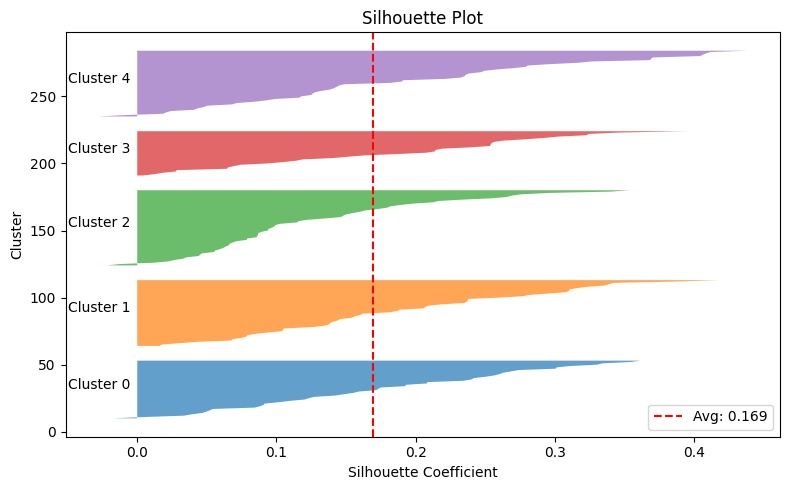

In [3]:
from sklearn.metrics import silhouette_samples, silhouette_score

sil_avg = silhouette_score(X_reduced, labels)
sil_values = silhouette_samples(X_reduced, labels)
print(f"Average Silhouette Score: {sil_avg:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for cid in sorted(set(labels)):
    cluster_sil = np.sort(sil_values[labels == cid])
    size = len(cluster_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f"Cluster {cid}")
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color="red", linestyle="--", label=f"Avg: {sil_avg:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Ground Truth Comparison

In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

gt_map = build_ground_truth_map()

# Per-column ground truth labels (one per column, matching labels length)
gt_labels = []
for col_idx in column_index:
    gt_label = gt_map.get(col_idx.upper(), "unknown")
    gt_labels.append(gt_label)

gt_labels = np.array(gt_labels)
ari = adjusted_rand_score(gt_labels, labels)
nmi = normalized_mutual_info_score(gt_labels, labels)

print(f"ARI: {ari:.4f}, NMI: {nmi:.4f}")
print(f"\nGround truth distribution ({len(gt_labels)} columns):")
for label in sorted(set(gt_labels)):
    print(f"  {label}: {(gt_labels == label).sum()} columns")

ct = pd.crosstab(pd.Series(gt_labels, name="Ground Truth"), pd.Series(labels, name="Cluster"))
print("\nCross-tabulation:")
print(ct)

ARI: -0.0065, NMI: 0.0352

Ground truth distribution (235 columns):
  clean: 29 columns
  eav: 6 columns
  giant_table: 90 columns
  impossible_data: 7 columns
  inconsistent_naming: 19 columns
  polymorphic: 16 columns
  reserved_words: 6 columns
  self_contradictory: 7 columns
  self_referencing: 6 columns
  wrong_data_types: 49 columns

Cross-tabulation:
Cluster               0   1   2   3   4
Ground Truth                           
clean                 5   7   7   1   9
eav                   1   3   2   0   0
giant_table          20  19  21  12  18
impossible_data       1   1   2   1   2
inconsistent_naming   5   4   5   4   1
polymorphic           2   2   7   2   3
reserved_words        0   2   2   1   1
self_contradictory    1   1   2   1   2
self_referencing      2   1   1   1   1
wrong_data_types      7  10   8  11  13


## 4. Visualization

/Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


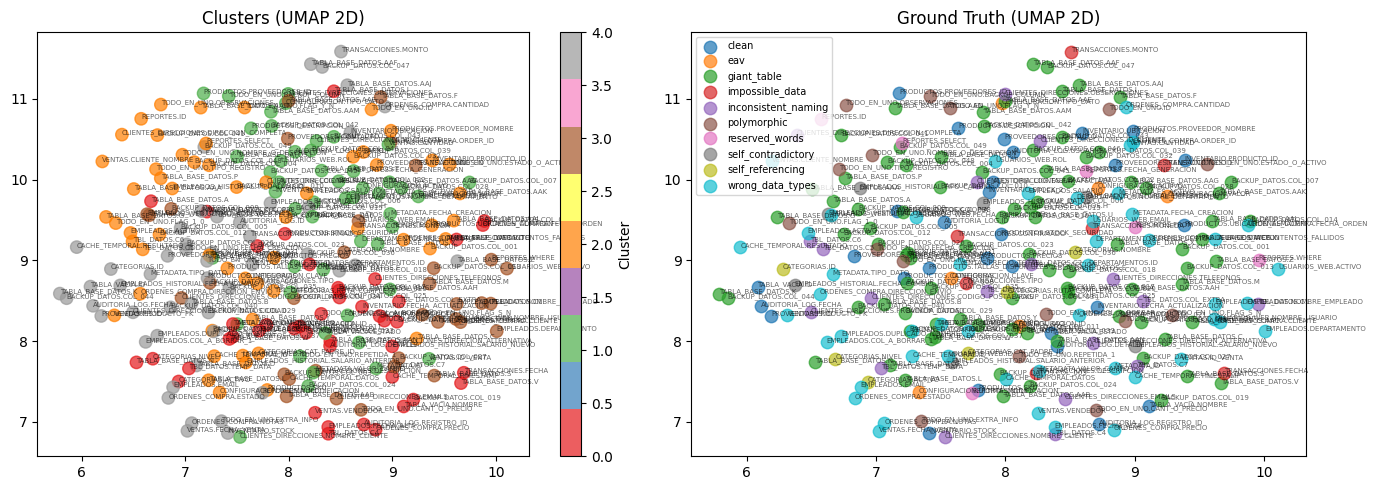

In [5]:
from dimensionality_reducer import DimensionalityReducer

umap_2d = DimensionalityReducer(method="umap", n_components=2)
X_2d = umap_2d.fit_transform(phi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="Set1", alpha=0.7, s=80)
for i, name in enumerate(column_index):
    axes[0].annotate(name, (X_2d[i, 0], X_2d[i, 1]), fontsize=5, alpha=0.6)
axes[0].set_title("Clusters (UMAP 2D)")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

unique_gt = np.unique(gt_labels)
for i, gt in enumerate(unique_gt):
    mask = gt_labels == gt
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], label=gt, alpha=0.7, s=80)
for i, name in enumerate(column_index):
    axes[1].annotate(name, (X_2d[i, 0], X_2d[i, 1]), fontsize=5, alpha=0.6)
axes[1].set_title("Ground Truth (UMAP 2D)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 5. Save for Notebook 04

In [6]:
intermediate = {
    "labels": labels, "gt_labels": gt_labels, "table_names": table_names,
    "X_reduced": X_reduced, "X_2d": X_2d, "phi": phi,
    "schema": schema, "all_columns": all_columns,
    "sil_values": sil_values, "sil_avg": sil_avg,
    "ari": ari, "nmi": nmi, "column_index": column_index,
}

save_path = Path.cwd().parent / "output" / "intermediate_03.pkl"
with open(save_path, "wb") as f:
    pickle.dump(intermediate, f)

print(f"Saved to {save_path} — ARI: {ari:.4f}, NMI: {nmi:.4f}")

Saved to /Users/jesusmarentes/Documents/Documents - MacBook Air de Jesús/db_bad_clust/output/intermediate_03.pkl — ARI: -0.0065, NMI: 0.0352
